In [88]:
import copy, math, os, pickle, time, pandas as pd, numpy as np, scipy.stats as ss, pathlib as pl, gc

from pathlib import Path

from matplotlib import pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay, precision_recall_curve, average_precision_score, roc_auc_score, accuracy_score, f1_score, confusion_matrix
from sklearn.calibration import CalibrationDisplay

# import torch, torch.utils.data as utils, torch.nn as nn, torch.nn.functional as F, torch.optim as optim
# from torch.autograd import Variable
# from torch.nn.parameter import Parameter

In [ ]:
#GAP_TIME          = 6  # In hours.  I don't need this as there is already a gap between end of data and predicted outcome (at 7 days)
WINDOW_SIZE       = 49 # In hours.  For my project, this is 49 hours as I have 24 hours prior to ICU inttime, 24 hours in ICU.  
SEED              = 1
ID_COLS           = ['subject_id', 'hadm_id', 'icustay_id']
ID_COLS_HOURLY = ID_COLS + ['hours_in']
TESTING = False          # set False for the full cohort run
PROJECT_ROOT = Path.cwd().parents[0]   # adjust after checking Path.cwd()
print(PROJECT_ROOT)
FLAT_DATA_PATH = PROJECT_ROOT / 'results' / 'models' / 'flat_data.pkl'  # location to save the processed data (train/dev/test) for later model evaluation
PLOTS_DIR = PROJECT_ROOT / 'results'/ 'plots'

np.random.seed(SEED)
#torch.manual_seed(SEED)

c:\Users\lizcr\OneDrive\Documents\MSc\Project\msc_project


In [90]:
class DictDist():
    def __init__(self, dict_of_rvs): self.dict_of_rvs = dict_of_rvs
    def rvs(self, n):
        a = {k: v.rvs(n) for k, v in self.dict_of_rvs.items()}
        out = []
        for i in range(n): out.append({k: vs[i] for k, vs in a.items()})
        return out
    
class Choice():
    def __init__(self, options): self.options = options
    def rvs(self, n): return [self.options[i] for i in ss.randint(0, len(self.options)).rvs(n)]

In [91]:
import getpass
from sqlalchemy import create_engine

pg_user = 'postgres'      # same value you use to connect via psql
pg_host = 'localhost'          # or wherever your Postgres server is
pg_port = 5432
pg_dbname = 'mimiciv'

pg_password = getpass.getpass('Postgres password: ')

engine = create_engine(
    f'postgresql+psycopg2://{pg_user}:{pg_password}@{pg_host}:{pg_port}/{pg_dbname}'
)

The following cells create the datasets - these are saved as pickle files and can be picked up just before sklearn section

In [92]:
# Delete the imputed dataframs to save memory (if previously created)?
# gc.collect()

In [93]:
%%time

# Read in hourly dataset


hourly_table = 'msc_project.sample_hourly_data' if TESTING else 'msc_project.hourly_data'

hourly_query = f"SELECT * FROM {hourly_table}"

data_full_lvl2 = (
    pd.read_sql(hourly_query, engine)
    .set_index(ID_COLS_HOURLY)
    .drop(columns='hour_end')   # dropping hour_end as it is redundant - hours_in tracks time since admission.
    .astype('float32')              # data type should be float (dealing with potential for all missing values). 
                                    # can specify float32 rather than default float64 to reduce memory usage.
)



CPU times: total: 46.9 ms
Wall time: 162 ms


In [94]:
%%time
# read in static data

statics_table = 'msc_project.sample_allpatients' if TESTING else 'msc_project.allpatients'

statics_query = f"SELECT * FROM {statics_table}"

statics = pd.read_sql(statics_query, engine).set_index(ID_COLS)

CPU times: total: 15.6 ms
Wall time: 8.75 ms


In [95]:
%%time

# read in the alternative representation data

alt_table = 'msc_project.sample_alternative_data' if TESTING else 'msc_project.alternative_data'

alt_query = f"SELECT * FROM {alt_table}"

data_full_alt = pd.read_sql(alt_query, engine)


CPU times: total: 31.2 ms
Wall time: 14.6 ms


In [96]:
""""
Adapted from the MIMIC-Extract function 'simple_imputer' in mimic3benchmark.preprocessing.utils, which
deals with missing values in the hourly data. The original function takes a dataframe with a multi-index of 
(subject_id, hadm_id, icustay_id, hours_in) and columns with a multi-index of (label, LEVEL1, LEVEL2, 
Aggregation Function). The function fills in missing values for the 'mean' aggregation function using 
forward fill and the mean of the icustay, and creates a 'mask' column indicating whether the original value 
was present or not. It also calculates the time since the last measurement for each variable.

This adaptation takes a dataframe with only one column per variable for the mean per hour. This is indexed by 
the ID columns and hour. If there is no measurement in a given hour, it is supplied as NaN in the input. 

I have made a decision to forward fill the missing values, but not to fill missing values at the start with the 
mean. It seems incorrect to impute values for hours before the first measurement - I do not want to use measures from 
after the relevant time point to impute values for before the first measurement.

"""

def simple_imputer(df, id_cols=ID_COLS):

    df = df.copy()
    # NB the forward fill depends on hours_in being in order for each stay.
    df = df.sort_index()    # Therefore sort. The index has been set earlier to be the ID_COLS + ['hours_in'] for the hourly data.

    mask = df.notna().astype(float)    # see later for why we convert to float. This is the mask of whether a 
                                        # measurement was present or not.
    imputed = (
        df.groupby(level=id_cols).ffill()              # forward fills from the last measurement.
        .fillna(0)
    )

    # grouping by stay here, this will mean that the last observed time should be only within the stay, 
    # not across other stays as in the original notebook. 
    is_absent = 1 - mask                # This is now 1 if the measurement is absent, 0 if there is a measurement.
    total_hours_of_absence = is_absent.groupby(level=id_cols).cumsum()   # cumulative sum of hours with no measurement for the stay.
    absent_hours_before_last_measure = (
        total_hours_of_absence[is_absent == 0]
        .groupby(level=id_cols).ffill()   
    )   # This is the number of absent hours before the latest measurement. 
    hours_since_last_measure = (total_hours_of_absence - absent_hours_before_last_measure).fillna(100)  # 100 is beyond the max hours covered in my data.

    df_out = pd.concat(
        [imputed, mask, hours_since_last_measure],             # temporary - include all of the measures to review progress. 
        axis = 1,
        keys = ['mean', 'mask', 'hours_since_last_measure']     # rename imputed as mean to match the Wang pipeline code.
    )

    # Carrying out renaming and restructuring here to work with later code from the Wang pipeline.
    df_out.columns.names = ['Aggregation Function', 'variable']     # need top level names
    df_out = df_out.swaplevel(0, 1, axis=1)                           # swap levels so variable is top level, aggregation next, to match Wang pipeline.
    df_out.sort_index(axis=1, inplace=True)                             # sort index to be consistent with the Wang pipeline.

    return df_out

In [97]:
""""
Adapted from the MIMIC-Extract cell in the notebook 'Baselines for Mortality and LOS prediction - SKlearn.ipynb'
in mimic3benchmark.preprocessing.utils, which splits the data into train, dev and test sets and also deals 
with standardisation.   
Updates compared to the original code:
- Removed the raw dataset as I am not using it.
- limited to a single outcome, length of stay after 7 days from ICU admission.
- No truncation based on the number of hours in the ICU, as this has already been done in my SQL processing.
- No use of GAP_TIME to ensure a gap between the end of the data and the predicted outcome, as there is already a gap between the last 
time point at 24 hours post-ICU admission and the predicted outcome at 7 days post ICU admission.
-- standardizing before calling the imputer, so that:
----- standardization is based on the real values available (check what happens in the Wang pipeline to see if this is different)
----- the imputation with zero in simple_imputer() will fill in with zero as the population (train data) mean, more appropriate than zero as an observation
"""


Ys = statics[['los_icu']].copy()  # No need to filter for max_hours > WINDOW_SIZE + GAP_TIME as this check is done in the SQL query for the hourly data. GAP_TIME is not needed as there is already a gap between the end of the data and the predicted outcome (at 7 days). 
Ys['los_7'] = (Ys['los_icu'] > 7).astype(float) # Amending to convert to float - original line didn't modify Ys.
Ys.drop(columns=['los_icu'], inplace=True)  

# Restrict to stays that are in Ys i.e. have a label
data_full_lvl2 = data_full_lvl2[
    data_full_lvl2.index.get_level_values('icustay_id').isin(
        set(Ys.index.get_level_values('icustay_id'))
    )
]
data_full_alt = data_full_alt[data_full_alt['icustay_id'].isin(
    set(Ys.index.get_level_values('icustay_id'))
)]

# Split into train, test and dev by subject_id
train_frac, dev_frac, test_frac = 0.7, 0.1, 0.2  # can move this to setup at start.
lvl2_subj_idx, Ys_subj_idx = [df.index.get_level_values('subject_id') for df in (data_full_lvl2, Ys)] # no raw dataset.
lvl2_subjects = set(lvl2_subj_idx)
assert lvl2_subjects == set(Ys_subj_idx), "Subject ID pools differ!"

np.random.seed(SEED)
subjects, N = np.random.permutation(list(lvl2_subjects)), len(lvl2_subjects)
N_train, N_dev, N_test = int(train_frac * N), int(dev_frac * N), int(test_frac * N)
train_subj = subjects[:N_train]
dev_subj   = subjects[N_train:N_train + N_dev]
test_subj  = subjects[N_train+N_dev:]

[(lvl2_train, lvl2_dev, lvl2_test), (Ys_train, Ys_dev, Ys_test)] = [     # again no raw dataset.
    [df[df.index.get_level_values('subject_id').isin(s)] for s in (train_subj, dev_subj, test_subj)] \
    for df in (data_full_lvl2, Ys)
]

alt_train, alt_dev, alt_test = [
    data_full_alt[data_full_alt['subject_id'].isin(s)] for s in (train_subj, dev_subj, test_subj)
    ]


# Now standardize the hourly dataset before calling simple_imputer()
lvl2_means = lvl2_train.mean(axis=0)
lvl2_stds = lvl2_train.std(axis=0)
lvl2_stds = lvl2_stds.replace(0,1)  # If std is zero, can replace with 1 to avoid division by zero in the below standardisation step.

lvl2_train = (lvl2_train - lvl2_means) / lvl2_stds
lvl2_dev = (lvl2_dev - lvl2_means) / lvl2_stds
lvl2_test = (lvl2_test - lvl2_means) / lvl2_stds




In [98]:
# Deal with missing values - hourly representation

# Now impute  # Call simple_imputer() to get the structure expected in the Wang pipeline
lvl2_train, lvl2_dev, lvl2_test = [
    simple_imputer(df) for df in (lvl2_train, lvl2_dev, lvl2_test)
]

# delete the non-imputed versions to save space here??

# Standardize for hours since last measure, which has been added to the hourly representation, to avoid problems with scale:
idx = pd.IndexSlice  # add to config at start?
hslm_means, hslm_stds = lvl2_train.loc[:, idx[:, 'hours_since_last_measure']].mean(axis=0), lvl2_train.loc[:, idx[:, 'hours_since_last_measure']].std(axis=0),
hslm_stds = hslm_stds.replace(0, 1)

lvl2_train.loc[:, idx[:, 'hours_since_last_measure']] = (lvl2_train.loc[:, idx[:, 'hours_since_last_measure']] - hslm_means)/hslm_stds
lvl2_dev.loc[:, idx[:,'hours_since_last_measure']] = (lvl2_dev.loc[:, idx[:,'hours_since_last_measure']] - hslm_means)/hslm_stds
lvl2_test.loc[:, idx[:,'hours_since_last_measure']] = (lvl2_test.loc[:, idx[:,'hours_since_last_measure']] - hslm_means)/hslm_stds

In [99]:
for name, df in [('lvl2_train', lvl2_train), ('lvl2_dev', lvl2_dev), ('lvl2_test', lvl2_test)]:
    counts = df.groupby(level=['subject_id', 'hadm_id', 'icustay_id']).size()
    print(name, counts.value_counts())

lvl2_train 49    35
Name: count, dtype: int64
lvl2_dev 49    5
Name: count, dtype: int64
lvl2_test 49    10
Name: count, dtype: int64


In [100]:
for name, df in [('lvl2_train', lvl2_train), ('lvl2_dev', lvl2_dev), ('lvl2_test', lvl2_test)]:
    n = df.isnull().sum().sum()
    print(name, n)

lvl2_train 0
lvl2_dev 0
lvl2_test 0


In [101]:
# pivot the hourly representation to wide:
# raw_train, raw_dev, raw_test, lvl2_train, lvl2_dev, lvl2_test = [                 # no need to call simple_imputer() here, as it's been called earlier on the full dataset.
#     simple_imputer(df) for df in (raw_train, raw_dev, raw_test, lvl2_train, lvl2_dev, lvl2_test)
# ]
lvl2_flat_train, lvl2_flat_dev, lvl2_flat_test = [                                  # removed the raw datasets.
    df.unstack('hours_in') for df in (
        lvl2_train, lvl2_dev, lvl2_test
    )
]

# alt representation - pivot to wide
alt_flat_train, alt_flat_dev, alt_flat_test = [
    df.set_index([
        'subject_id', 'hadm_id', 'icustay_id', 'variable_name'
        ]
        ).unstack('variable_name') for df in (alt_train, alt_dev, alt_test)
]

#lvl2_flat_train.head()
alt_flat_train.head()


value_min                                  \
variable_name                        dbp dbp_ni glucose_vital heart_rate   
subject_id hadm_id  icustay_id                                             
10164613   22813323 39738251        38.0   38.0         130.0       60.0   
10364182   28207940 30898648        55.0   55.0         116.0       75.0   
10544642   27891616 37540625        46.0    NaN          97.0       61.0   
10627029   29472934 31658321        49.0   49.0          73.0       62.0   
11001569   23809683 30851202        53.0   53.0         114.0       66.0   

                                                                           \
variable_name                    mbp mbp_ni resp_rate    sbp sbp_ni  spo2   
subject_id hadm_id  icustay_id                                              
10164613   22813323 39738251    46.0   46.0      15.0   83.0   83.0  92.0   
10364182   28207940 30898648    73.0   73.0      19.0  111.0  111.0  92.0   
10544642   27891616 37540625    58.0    NaN      12.0   83.0    NaN  98.0   
10627029   29472934 31658321    67.0   67.0      10.0  110.0  110.0  91.0   
11001569   23809683 30851202    67.0   67.0      12.5   93.0   93.0  98.0   

                                ... value_slope                           \
variable_name                   ...      dbp_ni glucose_vital heart_rate   
subject_id hadm_id  icustay_id  ...                                        
10164613   22813323 39738251    ...    0.070590     -2.049330  -0.707450   
10364182   28207940 30898648    ...   -0.457846     -2.782534  -0.700579   
10544642   27891616 37540625    ...         NaN      0.003303   1.232891   
10627029   29472934 31658321    ...    0.503614     -1.595810  -1.564828   
11001569   23809683 30851202    ...   -0.002651     -1.471678   0.242243   

                                                                        \
variable_name                        mbp    mbp_ni resp_rate       sbp   
subject_id hadm_id  icustay_id                                           
10164613   22813323 39738251   -0.486040 -0.486040 -0.414266 -2.018872   
10364182   28207940 30898648   -0.102651 -0.102651  0.198880  0.200226   
10544642   27891616 37540625   -0.277400       NaN  0.215358  0.096880   
10627029   29472934 31658321    0.395344  0.395344 -0.079678  0.080221   
11001569   23809683 30851202   -0.079397 -0.079397  0.076257  0.093893   

                                                                
variable_name                     sbp_ni      spo2 temperature  
subject_id hadm_id  icustay_id                                  
10164613   22813323 39738251   -2.018872 -0.070762   -0.003522  
10364182   28207940 30898648    0.200226 -0.126256    0.022268  
10544642   27891616 37540625         NaN -0.045835    0.126236  
10627029   29472934 31658321    0.080221  0.068788    0.000296  
11001569   23809683 30851202    0.093893  0.000644    0.023972  

[5 rows x 110 columns]

In [102]:
for name, df in [('lvl2_flat_train', lvl2_flat_train), ('lvl2_flat_dev', lvl2_flat_dev), ('lvl2_flat_test', lvl2_flat_test)]:
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    print(name, '-', len(nulls), 'columns affected out of', df.shape[1])
    print(nulls.head(50))

lvl2_flat_train - 0 columns affected out of 4704
Series([], dtype: int64)
lvl2_flat_dev - 0 columns affected out of 4704
Series([], dtype: int64)
lvl2_flat_test - 0 columns affected out of 4704
Series([], dtype: int64)


In [103]:
print(lvl2_train.shape)        # long format, pre-pivot - sanity check
print(lvl2_flat_train.shape)   # wide format, post-pivot
print(lvl2_flat_train.columns.duplicated().sum())

(1715, 96)
(35, 4704)
0


In [104]:
# Make sure I have a row for every ICU stay for alt representation - this may not be the case if any had no obs at all

alt_flat_train = alt_flat_train.reindex(Ys_train.index)
alt_flat_dev = alt_flat_dev.reindex(Ys_dev.index)
alt_flat_test = alt_flat_test.reindex(Ys_test.index)

In [105]:
# Deal with missing values - alt representation

# For alternative representation, missing values need decisions - cannot forwardfill and mask as for the hourly representation.

for df in (alt_flat_train, alt_flat_dev, alt_flat_test):
    n_missing = df.isnull().sum().sum()
    if n_missing:
        print(f"{n_missing} missing values")

216 missing values
2 missing values
170 missing values


In [106]:
# Add missingness indicator for those ICU stays where a variable is never observed, based on value count being NaN
# NB this means no observations during the stay, does not involve missing values for derived variables e.g. where standard deviation is zero
# Then, I will impute with the mean from the training data
# This missingness indicator will be added after standardization

alt_missing_train, alt_missing_dev, alt_missing_test = [
    df['value_count'].isnull().astype(int)
    for df in (alt_flat_train, alt_flat_dev, alt_flat_test)
]

# need to add column level to indicate this is a new measure missing_value, for each of the concepts

for df in (alt_missing_train, alt_missing_dev, alt_missing_test):
    df.columns = pd.MultiIndex.from_product([['value_missing'], df.columns])


alt_missing_train.head()
# These are now ready to add later

value_missing                                  \
variable_name                            dbp dbp_ni glucose_vital heart_rate   
subject_id hadm_id  icustay_id                                                 
15386345   20490942 32585414               0      0             0          0   
18583067   25650481 31835914               0      0             0          0   
17122654   27905430 35106498               0      0             0          0   
10544642   27891616 37540625               0      1             0          0   
11001569   23809683 30851202               0      0             0          0   

                                                                     \
variable_name                  mbp mbp_ni resp_rate sbp sbp_ni spo2   
subject_id hadm_id  icustay_id                                        
15386345   20490942 32585414     0      0         0   0      0    0   
18583067   25650481 31835914     0      0         0   0      0    0   
17122654   27905430 35106498     0      0         0   0      0    0   
10544642   27891616 37540625     0      1         0   0      1    0   
11001569   23809683 30851202     0      0         0   0      0    0   

                                            
variable_name                  temperature  
subject_id hadm_id  icustay_id              
15386345   20490942 32585414             0  
18583067   25650481 31835914             0  
17122654   27905430 35106498             0  
10544642   27891616 37540625             0  
11001569   23809683 30851202             0

In [107]:
# standardize alt representation  - (already done for hourly representation, prior to imputing missing data)
alt_means = alt_flat_train.mean(axis=0)
alt_stds = alt_flat_train.std(axis=0)  
alt_stds = alt_stds.replace(0, 1) # If std is zero, can replace with 1 to avoid division by zero in the below standardisation step. 

alt_flat_train = (alt_flat_train - alt_means) / alt_stds
alt_flat_dev = (alt_flat_dev - alt_means) / alt_stds
alt_flat_test = (alt_flat_test - alt_means) / alt_stds

In [108]:
# Missing data - fill missings with 0 - after standardization this represents the training average

alt_flat_train = alt_flat_train.fillna(0)
alt_flat_dev = alt_flat_dev.fillna(0)
alt_flat_test = alt_flat_test.fillna(0)

# Now add the missingness indicator variable previously generated

alt_flat_train = pd.concat([alt_flat_train, alt_missing_train], axis=1)
alt_flat_dev = pd.concat([alt_flat_dev, alt_missing_dev], axis=1)
alt_flat_test = pd.concat([alt_flat_test, alt_missing_test], axis=1)

In [109]:
for df in lvl2_flat_train, lvl2_flat_dev, lvl2_flat_test: assert not df.isnull().any().any()       # check for missings. removed the raw datasets.
for df in alt_flat_train, alt_flat_dev, alt_flat_test: assert not df.isnull().any().any()

In [110]:
# save the processed flat data for later model evaluation. 
with open(FLAT_DATA_PATH, mode = 'wb') as f:
    pickle.dump({
        'lvl2_flat_train': lvl2_flat_train,
        'lvl2_flat_dev': lvl2_flat_dev,
        'lvl2_flat_test': lvl2_flat_test,
        'alt_flat_train': alt_flat_train,
        'alt_flat_dev': alt_flat_dev,
        'alt_flat_test': alt_flat_test,
        'Ys_train': Ys_train,
        'Ys_dev': Ys_dev,
        'Ys_test': Ys_test
    }, f)

Task prediction

Hyperparameters

In [122]:
""""
Adapted from the MIMIC-Extract cell in the notebook 'Baselines for Mortality and LOS prediction - SKlearn.ipynb'
in mimic3benchmark.preprocessing.utils, which sets up hyperparameter distributions for logistic regression, random forest and GRU models.
To start with, I will set up only logistic regression and random forest models. I will begin using the same hyperparameters before 
considering adjustments.
2026-08-14 replaced penalty (deprecated) with l1_ratio.
"""

N = 8

LR_dist = DictDist({
    'C': Choice(np.geomspace(1e-3, 1e2, 10000)),  # I've reduced the range of options here 
    'l1_ratio': Choice([0, 0.5, 1]),
    #'penalty': Choice(['l1', 'l2', 'elasticnet']),  # penalty is now deprecated
    'solver': Choice(['liblinear', 'saga']),     # The convergence problems seem to be occuring when the solver is lbfgs so I will see what happens if it is only liblinear.
    'max_iter': Choice([100, 300])  # switched from 500 as the larger max iterations to 300.
})
np.random.seed(SEED)
LR_hyperparams_list = LR_dist.rvs(N)
for i in range(N):                              # liblinear does not support elasticnet
    if LR_hyperparams_list[i]['solver'] == 'liblinear' and LR_hyperparams_list[i]['l1_ratio'] == 0.5: 
        LR_hyperparams_list[i]['l1_ratio'] = np.random.choice([0, 1])

RF_dist = DictDist({
    'n_estimators': ss.randint(50, 500),
    'max_depth': ss.randint(2, 10),
    'min_samples_split': ss.randint(2, 75),
    'min_samples_leaf': ss.randint(1, 50),
})
np.random.seed(SEED)
RF_hyperparams_list = RF_dist.rvs(N)


Functions

In [125]:
test_M = LogisticRegression(l1_ratio=1, solver='liblinear', C=1.0, max_iter=100)
test_M.fit(lvl2_flat_train, Ys_train['los_7'])

,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization 

In [126]:
'''
These functions are from a MIMIC-Extract cell in the notebook 'Baselines for Mortality and LOS prediction - SKlearn.ipynb'
I have created an additional function select_hyperparameters() that does not move on to runnig the model on the test data
This will be used for initial exploration and decision making on hyperparameters to be sure of avoiding leakage.
Average precision score is used instead of roc_auc to choose hyperparameters.

'''

def select_hyperparameters(model, hyperparams_list, X_flat_train, X_flat_dev, target):
    '''
    This function is an addition to use to determine hyperparameters, which only runs the models 
    on the Dev dataset, not Test.
    Average precision score is used instead of roc_auc to choose hyperparameters.
    This is a better measure for the outcome which has a significant class imbalance.
    '''
    best_s, best_hyperparams = -np.inf, None
    for i, hyperparams in enumerate(hyperparams_list):
        print("On sample %d / %d (hyperparams = %s)" % (i+1, len(hyperparams_list), repr((hyperparams))))
        M = model(**hyperparams)
        M.fit(X_flat_train, Ys_train[target])
        s = average_precision_score(Ys_dev[target], M.predict_proba(X_flat_dev)[:, 1])
        if s > best_s:
            best_s, best_hyperparams, best_M = s, hyperparams, M
            print("New Best Score: %.2f @ hyperparams = %s" % (100*best_s, repr((best_hyperparams))))
    y_true  = Ys_dev[target]
    y_score = best_M.predict_proba(X_flat_dev)[:, 1]
    y_pred  = best_M.predict(X_flat_dev)

    auc   = roc_auc_score(y_true, y_score)
    auprc = average_precision_score(y_true, y_score)
    acc   = accuracy_score(y_true, y_pred)
    F1    = f1_score(y_true, y_pred)
    return best_M, best_hyperparams, auc, auprc, acc, F1

def run_basic(model, hyperparams_list, X_flat_train, X_flat_dev, X_flat_test, target):
    '''
    This may be run, with adjustments, after initial decision making on hyperparameters
    '''
    best_s, best_hyperparams = -np.inf, None
    for i, hyperparams in enumerate(hyperparams_list):
        print("On sample %d / %d (hyperparams = %s)" % (i+1, len(hyperparams_list), repr((hyperparams))))
        M = model(**hyperparams)
        M.fit(X_flat_train, Ys_train[target])
        s = roc_auc_score(Ys_dev[target], M.predict_proba(X_flat_dev)[:, 1])
        if s > best_s:
            best_s, best_hyperparams = s, hyperparams
            print("New Best Score: %.2f @ hyperparams = %s" % (100*best_s, repr((best_hyperparams))))

    return run_only_final(model, best_hyperparams, X_flat_train, X_flat_dev, X_flat_test, target)

def run_only_final(model, best_hyperparams, X_flat_train, X_flat_dev, X_flat_test, target):
    '''
    this may be run, with adjustments, after initial decision making on hyperparameters
    '''
    best_M = model(**best_hyperparams)
    best_M.fit(pd.concat((X_flat_train, X_flat_dev)), pd.concat((Ys_train, Ys_dev))[target])
    y_true  = Ys_test[target]
    y_score = best_M.predict_proba(X_flat_test)[:, 1]
    y_pred  = best_M.predict(X_flat_test)

    auc   = roc_auc_score(y_true, y_score)
    auprc = average_precision_score(y_true, y_score)
    acc   = accuracy_score(y_true, y_pred)
    F1    = f1_score(y_true, y_pred)
    
    return best_M, best_hyperparams, auc, auprc, acc, F1

Sklearn

In [26]:
""""
Adapted cell from 'Baselines for Mortality and LOS prediction - SKlearn.ipynb'
Added exception handling for the case where the results file does not exist yet.
"""

RESULTS_PATH = PROJECT_ROOT / 'results' / 'models' / 'extraction_baselines-sklearn.pkl'

try:
    with open(RESULTS_PATH, mode='rb') as f: 
        results = pickle.load(f)
except FileNotFoundError:
    results = {}

RERUN = True

In [ ]:

# # open the prepared datasets:
# with open(FLAT_DATA_PATH, mode = 'rb') as f:
#     data = pickle.load(f)
# lvl2_flat_train = data['lvl2_flat_train']
# lvl2_flat_dev = data['lvl2_flat_dev']
# Ys_train = data['Ys_train']
# Ys_dev = data['Ys_dev']
 

In [127]:
""""
Adapted cell from 'Baselines for Mortality and LOS prediction - SKlearn.ipynb'
I have made an adapted version of the cell where models are run. 
I am adapting the code to run only on the outcome length of stay 7 days after ICU admission, and to run only on 
the lvl2 representation of the data, not the raw version.
At this stage in the development of the project the models will only be run using the Dev dataset, not Test.

"""

for model_name, model, hyperparams_list in [
    ('LR', LogisticRegression, LR_hyperparams_list), ('RF', RandomForestClassifier, RF_hyperparams_list)
    ]:
    if model_name not in results:                           # no need for loop around outcomes as I have only one.
        results[model_name] = {}                            # retaining loop around representations. Although I don'have a raw dataset, I will have a separate representation at a later stage.
    for n, X_flat_train, X_flat_dev in (
        ('lvl2', lvl2_flat_train, lvl2_flat_dev),  
        ('alt', alt_flat_train, alt_flat_dev)
        ):
        print("Running model %s on target %s with representation %s" % (model_name, 'los_7', n)) 
        start_time = time.time()
        results[model_name][n] = select_hyperparameters(model, hyperparams_list, X_flat_train, X_flat_dev, 'los_7')
        elapsed_time = time.time() - start_time
        print(f"Time taken for {model_name} was {elapsed_time} seconds.")

        print("Final results for model %s on target %s with representation %s" % (model_name, 'los_7', n))
        print(results[model_name][n][2:])
        with open(RESULTS_PATH, mode='wb') as f: 
            pickle.dump(results, f)
        print(results[model_name][n])

Running model LR on target los_7 with representation lvl2
On sample 1 / 8 (hyperparams = {'C': np.float64(0.00131072550760276), 'l1_ratio': 0, 'solver': 'saga', 'max_iter': 100})
New Best Score: 100.00 @ hyperparams = {'C': np.float64(0.00131072550760276), 'l1_ratio': 0, 'solver': 'saga', 'max_iter': 100}
On sample 2 / 8 (hyperparams = {'C': np.float64(0.394693183437891), 'l1_ratio': np.int64(0), 'solver': 'liblinear', 'max_iter': 100})
On sample 3 / 8 (hyperparams = {'C': np.float64(0.002834949026579316), 'l1_ratio': 0, 'solver': 'liblinear', 'max_iter': 100})
On sample 4 / 8 (hyperparams = {'C': np.float64(8.070318765995962), 'l1_ratio': 1, 'solver': 'saga', 'max_iter': 300})


c:\Users\lizcr\OneDrive\Documents\MSc\Project\msc_project\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


On sample 5 / 8 (hyperparams = {'C': np.float64(0.02803139843638119), 'l1_ratio': np.int64(0), 'solver': 'liblinear', 'max_iter': 300})
On sample 6 / 8 (hyperparams = {'C': np.float64(0.3374837182125259), 'l1_ratio': 1, 'solver': 'liblinear', 'max_iter': 300})
On sample 7 / 8 (hyperparams = {'C': np.float64(0.0011803402058496162), 'l1_ratio': 0, 'solver': 'liblinear', 'max_iter': 300})
On sample 8 / 8 (hyperparams = {'C': np.float64(0.12963171632368953), 'l1_ratio': 1, 'solver': 'saga', 'max_iter': 300})


c:\Users\lizcr\OneDrive\Documents\MSc\Project\msc_project\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\lizcr\OneDrive\Documents\MSc\Project\msc_project\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\lizcr\OneDrive\Documents\MSc\Project\msc_project\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Time taken for LR was 1.8305399417877197 seconds.
Final results for model LR on target los_7 with representation lvl2
(1.0, 1.0, 0.8, 0.0)
(LogisticRegression(C=np.float64(0.00131072550760276), l1_ratio=0, solver='saga'), {'C': np.float64(0.00131072550760276), 'l1_ratio': 0, 'solver': 'saga', 'max_iter': 100}, 1.0, 1.0, 0.8, 0.0)
Running model LR on target los_7 with representation alt
On sample 1 / 8 (hyperparams = {'C': np.float64(0.00131072550760276), 'l1_ratio': 0, 'solver': 'saga', 'max_iter': 100})
New Best Score: 100.00 @ hyperparams = {'C': np.float64(0.00131072550760276), 'l1_ratio': 0, 'solver': 'saga', 'max_iter': 100}
On sample 2 / 8 (hyperparams = {'C': np.float64(0.394693183437891), 'l1_ratio': np.int64(0), 'solver': 'liblinear', 'max_iter': 100})
On sample 3 / 8 (hyperparams = {'C': np.float64(0.002834949026579316), 'l1_ratio': 0, 'solver': 'liblinear', 'max_iter': 100})
On sample 4 / 8 (hyperparams = {'C': np.float64(8.070318765995962), 'l1_ratio': 1, 'solver': 'saga', 

In [29]:
""""
Adapted cell from 'Baselines for Mortality and LOS prediction - SKlearn.ipynb'
This is the cell where the models are run. 
I am adapting the code to run only on the outcome length of stay 7 days after ICU admission, and to run only on 
the lvl2 representation of the data, not the raw version.
However this will only be used when the design decisions and hyperparameter selection are complete, to avoid
exploration and development occuring using the Test dataset.
"""

# for model_name, model, hyperparams_list in [
#     ('RF', RandomForestClassifier, RF_hyperparams_list), ('LR', LogisticRegression, LR_hyperparams_list)
#     ]:
#     if model_name not in results:                           # no need for loop around outcomes as I have only one.
#         results[model_name] = {}                            # retaining loop around representations. Although I don'have a raw dataset, I will have a separate representation at a later stage.
#     for n, X_flat_train, X_flat_dev, X_flat_test in (
#         ('lvl2', lvl2_flat_train, lvl2_flat_dev, lvl2_flat_test),  # retaining comma as this is a tuple with addition of another representation later
#         ):
#         if n in results[model_name]:
#             print("Finished model %s on target %s with representation %s" % (model_name, 'los_7', n))
#             if RERUN:
#                 h = results[model_name][n][1]       # gets the previous hyperparameters for that model and representation.
#                 results[model_name][n] = run_only_final(model, h, X_flat_train, X_flat_dev, X_flat_test, 'los_7')
#                 print("Final results for model %s on target %s with representation %s" % (model_name, 'los_7', n))
#                 print(results[model_name][n][2:])

#                 with open(RESULTS_PATH, mode='wb') as f: pickle.dump(results, f)
#             continue
#         print("Running model %s on target %s with representation %s" % (model_name, 'los_7', n))    # this is what happens if not yet run
#         results[model_name][n] = run_basic(model, hyperparams_list, X_flat_train, X_flat_dev, X_flat_test, 'los_7')
#         print("Final results for model %s on target %s with representation %s" % (model_name, 'los_7', n))
#         print(results[model_name][n][2:])
#         with open(RESULTS_PATH, mode='wb') as f: 
#             pickle.dump(results, f)

'"\nAdapted cell from \'Baselines for Mortality and LOS prediction - SKlearn.ipynb\'\nThis is the cell where the models are run. \nI am adapting the code to run only on the outcome length of stay 7 days after ICU admission, and to run only on \nthe lvl2 representation of the data, not the raw version.\nHowever this will only be used when the design decisions and hyperparameter selection are complete, to avoid\nexploration and development occuring using the Test dataset.\n'

Reporting results

In [30]:
# review results

summary_dict = {}
for model_name in ('RF', 'LR'):
    summary_dict[model_name] = {}
    for n in ('lvl2', 'alt'):
        summary_dict[model_name][n] = {
            'AUC-ROC': results[model_name][n][2],
            'AUPRC': results[model_name][n][3],
            'Accuracy': results[model_name][n][4],
            'F1': results[model_name][n][5],
    }
summary_dict

{'RF': {'lvl2': {'AUC-ROC': 0.5, 'AUPRC': 0.2, 'Accuracy': 0.8, 'F1': 0.0},
  'alt': {'AUC-ROC': 1.0, 'AUPRC': 1.0, 'Accuracy': 0.8, 'F1': 0.0}},
 'LR': {'lvl2': {'AUC-ROC': 1.0, 'AUPRC': 1.0, 'Accuracy': 0.8, 'F1': 0.0},
  'alt': {'AUC-ROC': 1.0, 'AUPRC': 1.0, 'Accuracy': 1.0, 'F1': 1.0}}}

In [31]:
# look at class imbalance
print(Ys_train['los_7'].value_counts())
print(Ys_dev['los_7'].value_counts())
#print(Ys_test['los_7'].value_counts())

los_7
0.0    31
1.0     4
Name: count, dtype: int64
los_7
0.0    4
1.0    1
Name: count, dtype: int64


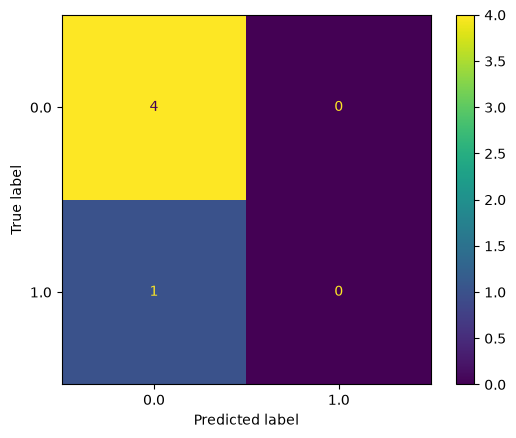

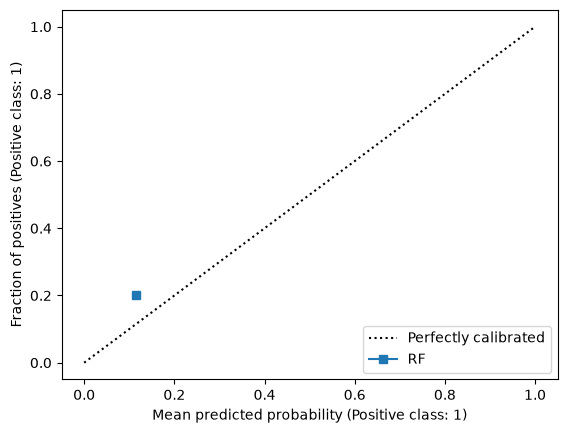

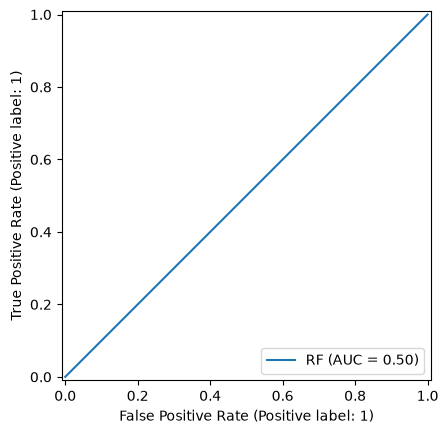

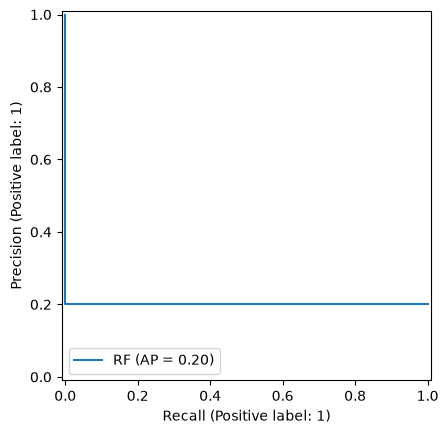

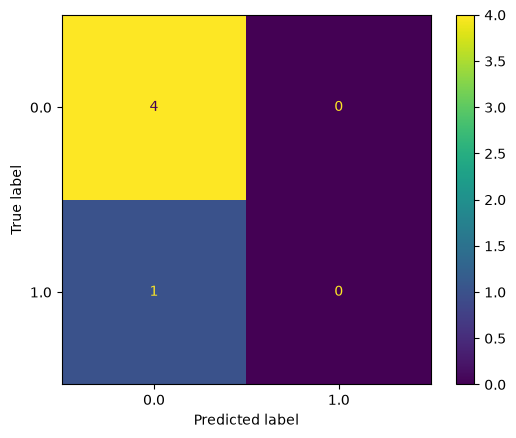

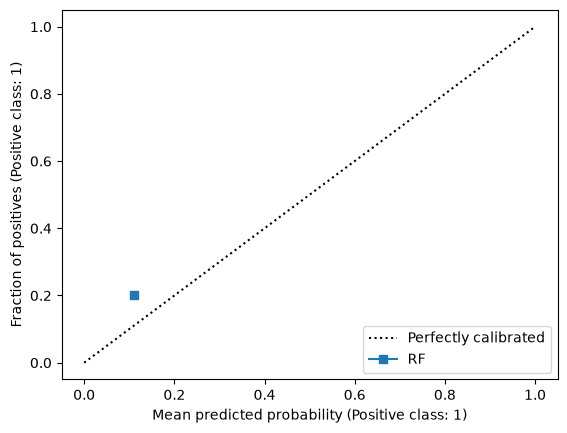

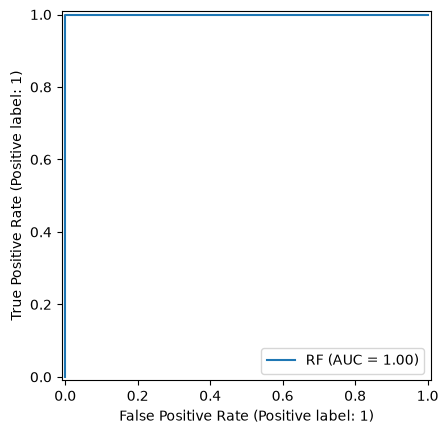

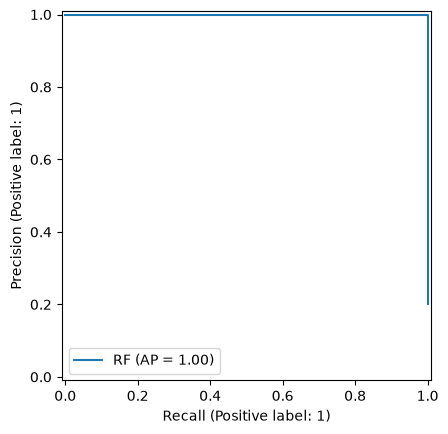

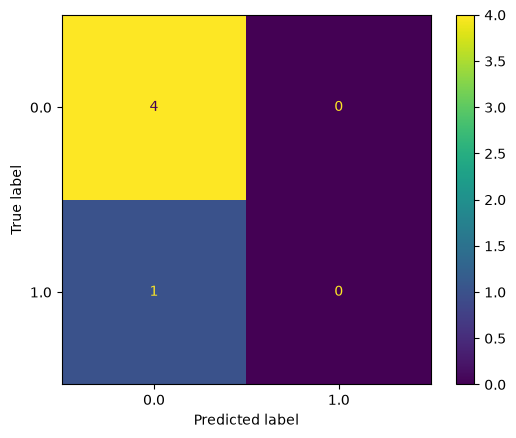

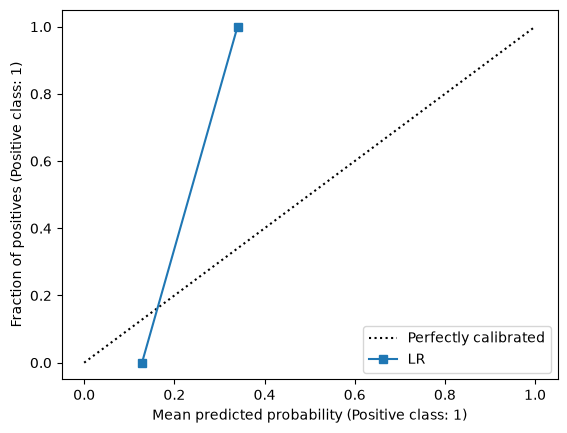

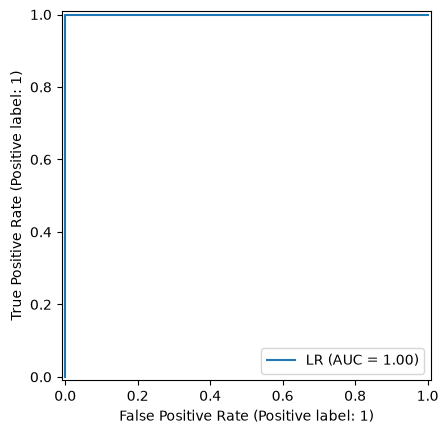

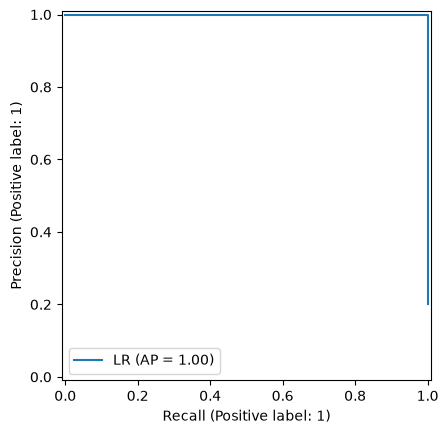

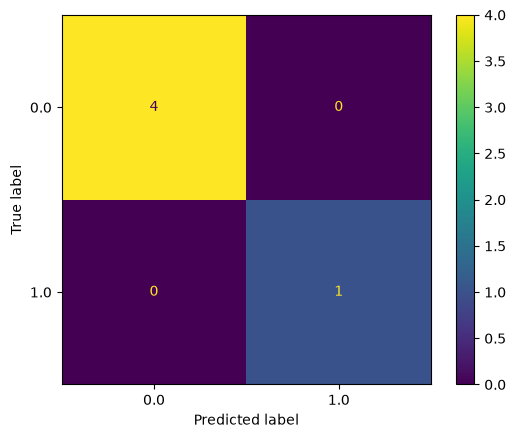

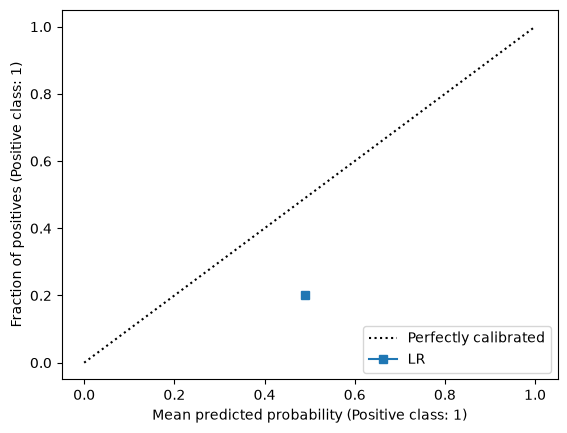

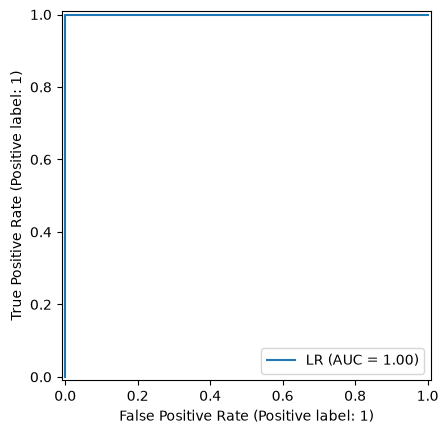

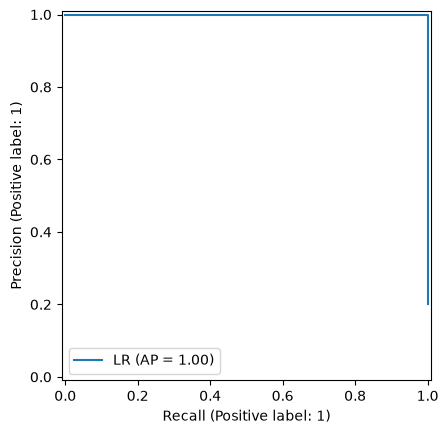

In [32]:
# confusion matrix and plots for both RF and LR together

flat_dev = {'lvl2': lvl2_flat_dev, 'alt': alt_flat_dev}

for model_name in ('RF', 'LR'):
    for n in ('lvl2', 'alt'):
        best_M = results[model_name][n][0]
        y_true = Ys_dev['los_7']            # should be looking at dev not test
        y_pred = best_M.predict(flat_dev[n])  # should be looking at dev not test
        y_prob = best_M.predict_proba(flat_dev[n])[:, 1]

        # confusion matrix:
        matrix = ConfusionMatrixDisplay.from_predictions(y_true, y_pred)
        matrix.figure_.savefig(PLOTS_DIR / f'confusion_matrix_{model_name}_{n}.png')

        # calibration plot
        calib_plot = CalibrationDisplay.from_predictions(y_true, y_prob, name = model_name)
        calib_plot.figure_.savefig(PLOTS_DIR / f'calibration_{model_name}_{n}.png')

        # auc-roc
        auc_roc_plot = RocCurveDisplay.from_predictions(y_true, y_prob, name = model_name)
        auc_roc_plot.figure_.savefig(PLOTS_DIR / f'auc_roc_{model_name}_{n}.png')

        # au-prc
        au_prc_plot = PrecisionRecallDisplay.from_predictions(y_true, y_prob, name = model_name)
        au_prc_plot.figure_.savefig(PLOTS_DIR / f'au_prc_{model_name}_{n}.png')

In [34]:
# find optimum threshold for sensitivity/specificity based on F1 score: LR
# Results on sample data are meaningless (same as for plots)

flat_dev = {'lvl2': lvl2_flat_dev, 'alt': alt_flat_dev}

best_thresholds = {}
for model_name in ('LR', 'RF'):
    for n in ('lvl2', 'alt'):
        best_M = results[model_name][n][0]
        y_true = Ys_dev['los_7']
        y_prob = best_M.predict_proba(flat_dev[n])[:, 1]

        precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
        print(precision)
        print(recall)
        print(thresholds)

        f1 = 2 * ((precision * recall) / (precision + recall + 1e-12)) # adding small addition to deal with zeros

        f1 = f1[:-1]  # remove last entry in array 
        f1idx = np.argmax(f1)
        print (f"Threshold for maximum F1 for {model_name}, {n}: {thresholds[f1idx]})")
        best_thresholds[(model_name, n)] = thresholds[f1idx]

[0.2        0.25       0.33333333 0.5        1.         1.        ]
[1. 1. 1. 1. 1. 0.]
[0.10067433 0.10577102 0.13662148 0.17006585 0.34012432]
Threshold for maximum F1 for LR, lvl2: 0.34012431922284597)
[0.2        0.25       0.33333333 0.5        1.         1.        ]
[1. 1. 1. 1. 1. 0.]
[0.46982674 0.48664582 0.49119874 0.49706731 0.50845274]
Threshold for maximum F1 for LR, alt: 0.5084527368573372)
[0.2 1. ]
[1. 0.]
[0.11559934]
Threshold for maximum F1 for RF, lvl2: 0.11559934318555)
[0.2 1.  1. ]
[1. 1. 0.]
[0.11084781 0.1124812 ]
Threshold for maximum F1 for RF, alt: 0.1124812030075185)


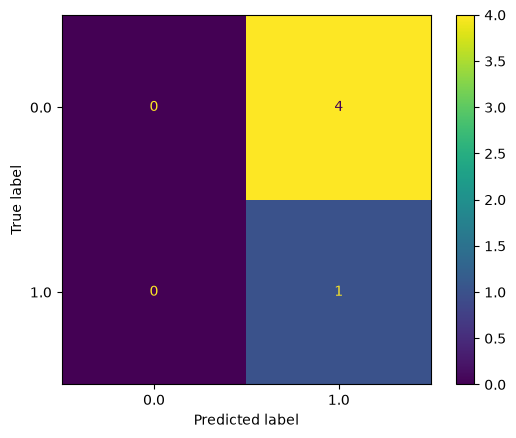

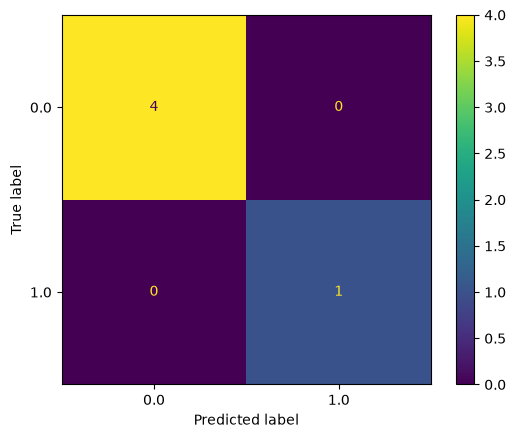

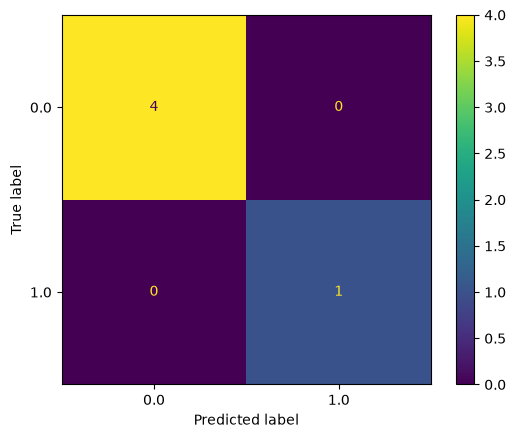

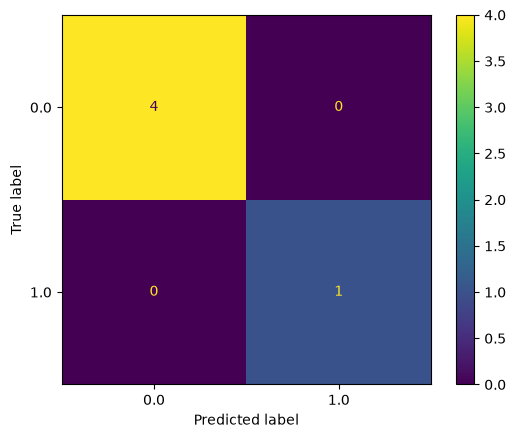

In [35]:
# Try confusion matrix with these thresholds.

flat_dev = {'lvl2': lvl2_flat_dev, 'alt': alt_flat_dev}

for model_name in ('RF', 'LR'):
    for n in ('lvl2', 'alt'):
        best_M = results[model_name][n][0]
        y_true = Ys_dev['los_7']       
        #y_pred = best_M.predict(lvl2_flat_dev)  
        y_prob = best_M.predict_proba(flat_dev[n])[:, 1]

        y_pred = (y_prob >= best_thresholds[(model_name, n)]).astype(float)  # using threshold extracted above

        # confusion matrix:
        matrix = ConfusionMatrixDisplay.from_predictions(y_true, y_pred)
        matrix.figure_.savefig(PLOTS_DIR / f'confusion_matrix_{model_name}_{n}.png')